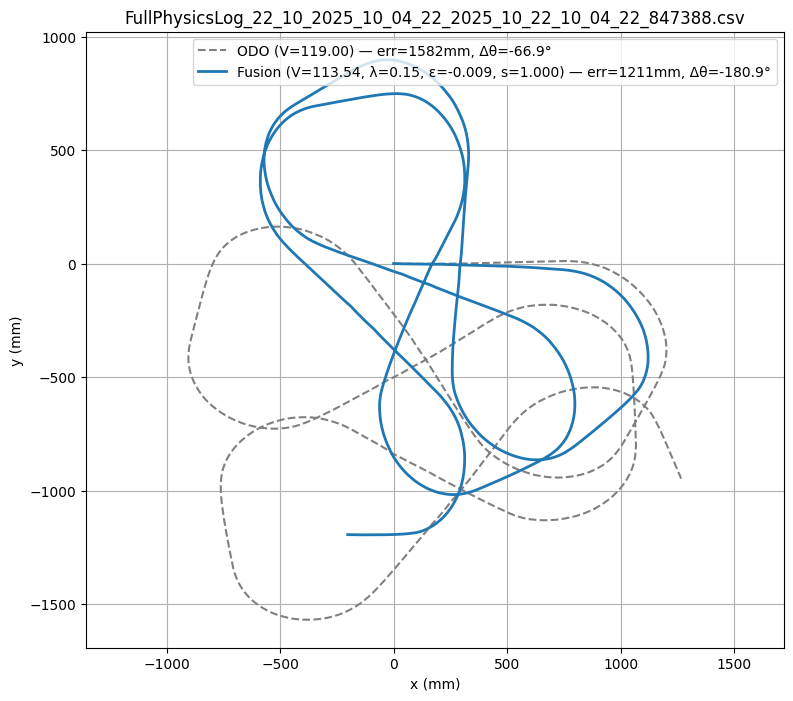

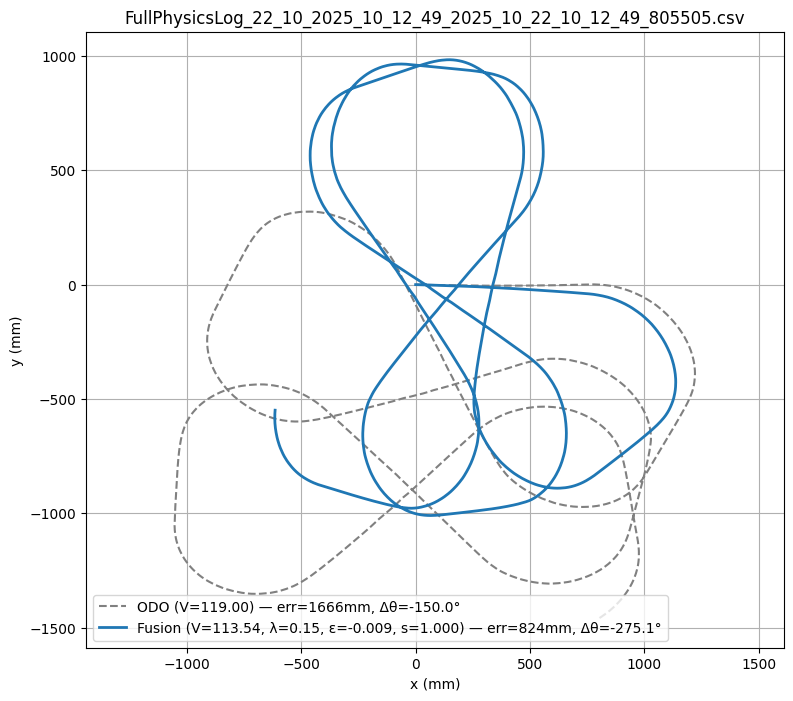

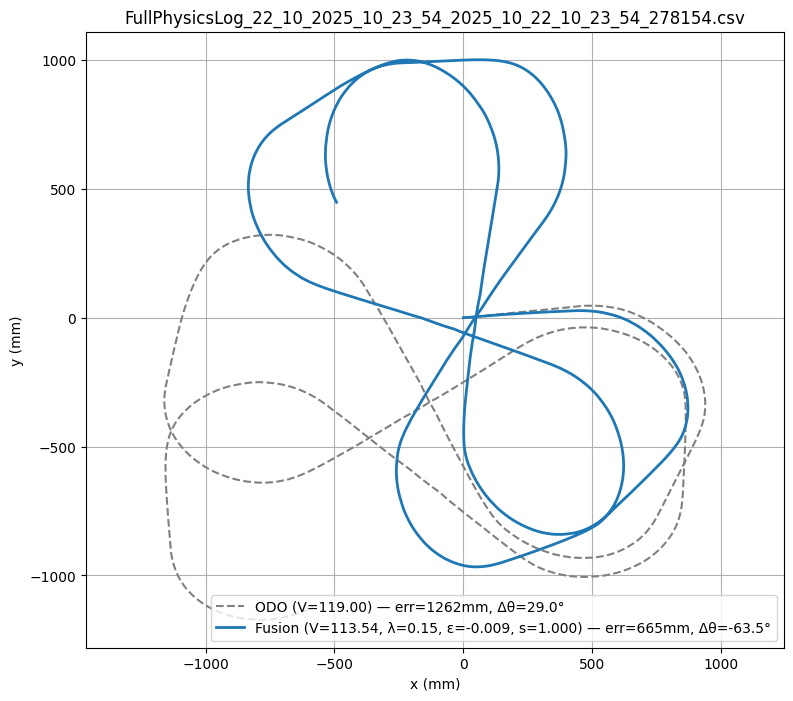

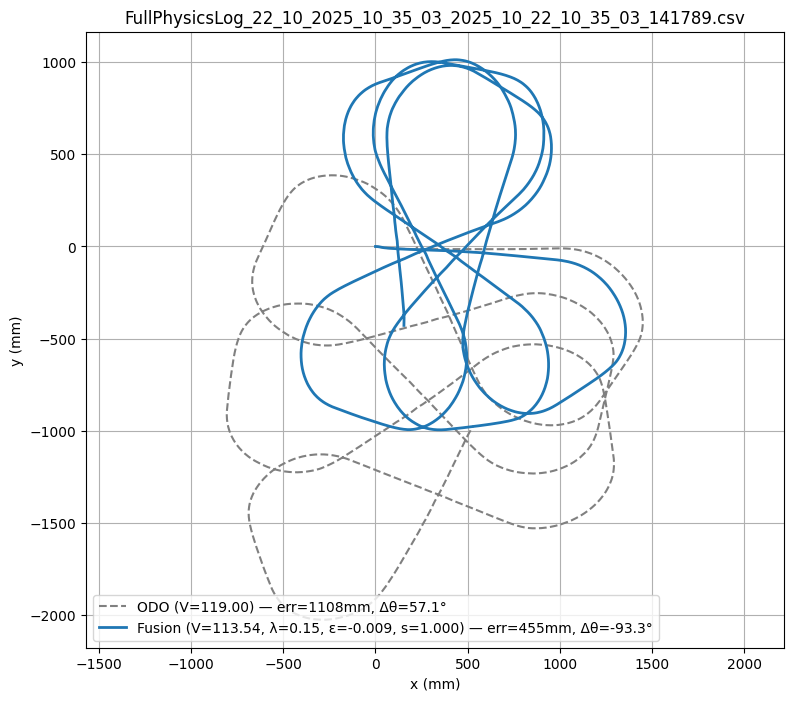

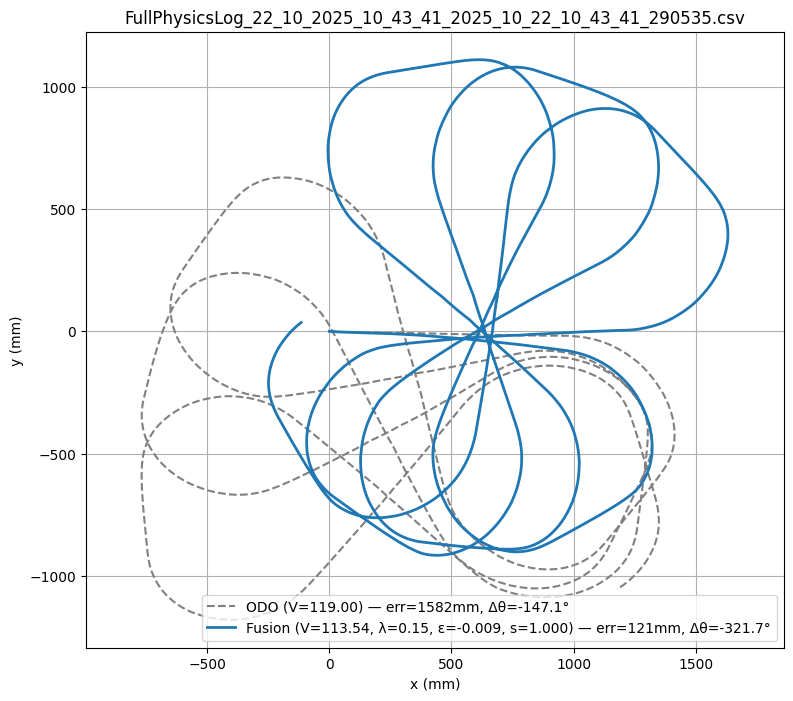

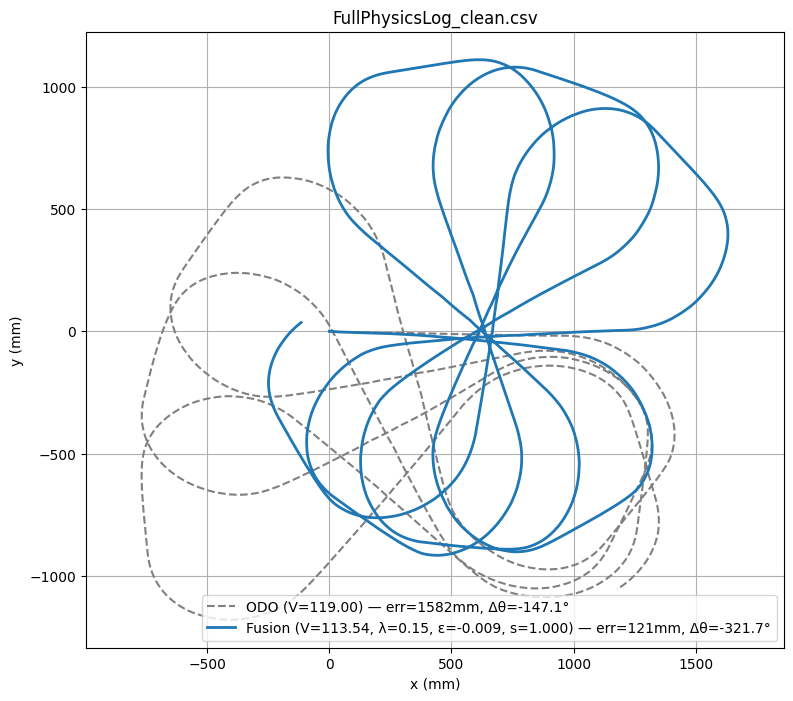

[SKIP] Colonnes vitesses manquantes: FullPhysicsLog_20_10_2025_17_04_54_2025_10_20_17_04_54_765075.csv


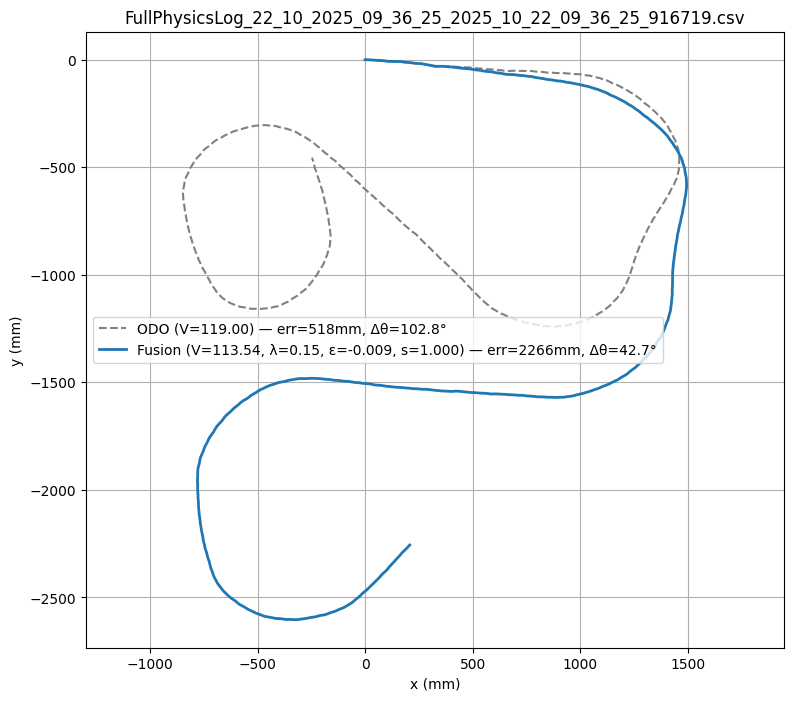

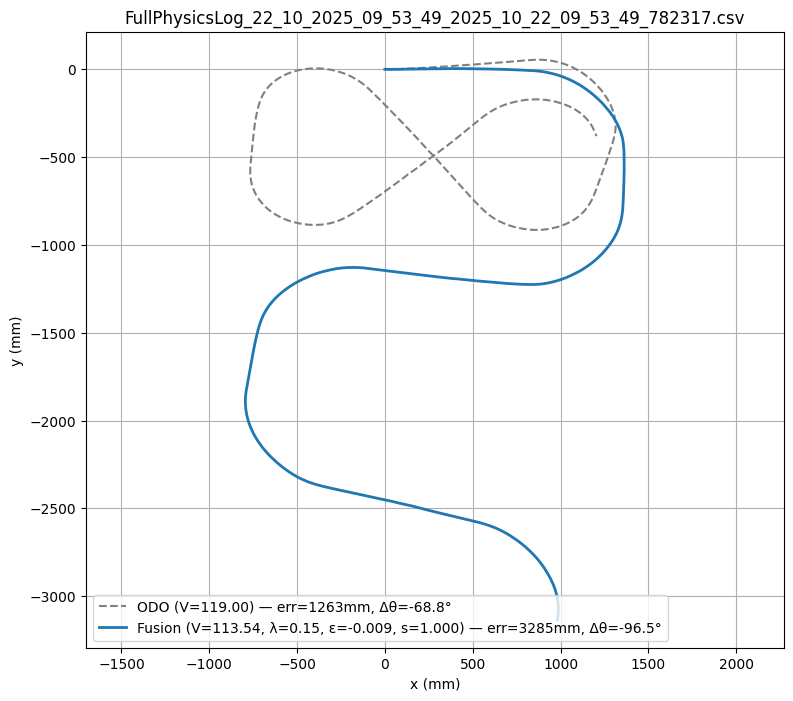

In [8]:
# Cellule unique — boucle sur les logs et affiche les courbes
import glob, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ Réglages ------------------
SEARCH_DIRS = [".", "old_logs"]          # dossiers à parcourir
PATTERN     = "FullPhysicsLog_*.csv"     # motif des logs
DT          = 0.1                        # pas fixe (s) pour l'intégration offline
V_ODO       = 119.0                      # voie pour la référence ODO (trace grise)

# Réglages "fusion" (ajuste si besoin)
V_FUS   = 113.54                         # voie pour la fusion
LAM_FUS = 0.15                           # poids gyro (0=odo pur, 1=gyro pur)
EPS_FUS = -0.009                         # asymétrie roues: vL'=(1-ε)vL, vR'=(1+ε)vR
S_FUS   = 1.000                          # scale linéaire global

# ------------------ Fonctions ------------------
def integrate_midpoint_odo(vL, vR, V, dt):
    """Odométrie pure (midpoint)."""
    v = (vL + vR) / 2.0
    w = (vR - vL) / float(V)
    n = len(v)
    x = np.zeros(n); y = np.zeros(n); th = np.zeros(n)
    for i in range(1, n):
        th_i = th[i-1] + w[i]*dt
        th_mid = 0.5*(th[i-1] + th_i)
        dd = v[i]*dt
        x[i] = x[i-1] + dd*np.cos(th_mid)
        y[i] = y[i-1] + dd*np.sin(th_mid)
        th[i] = th_i
    dx, dy = float(x[-1]-x[0]), float(y[-1]-y[0])
    err_xy = float(np.hypot(dx, dy))
    dtheta_deg = float(np.degrees(th[-1] - th[0]))
    return x, y, th, err_xy, dtheta_deg

def integrate_fusion_scaled(vL0, vR0, theta_gyro_deg, V, lam, eps, s, dt):
    """Fusion gyro + asymétrie + scale linéaire — intégration midpoint."""
    vL = (1.0 - eps) * (s * vL0)
    vR = (1.0 + eps) * (s * vR0)
    v  = (vL + vR) / 2.0
    w  = (vR - vL) / float(V)
    theta_gyro = np.radians(theta_gyro_deg)

    n = len(v)
    th_odo = np.zeros(n)
    for i in range(1, n):
        th_odo[i] = th_odo[i-1] + w[i]*dt
    th = (1.0 - lam)*th_odo + lam*theta_gyro

    x = np.zeros(n); y = np.zeros(n)
    for i in range(1, n):
        th_mid = 0.5*(th[i-1] + th[i])
        dd = v[i]*dt
        x[i] = x[i-1] + dd*np.cos(th_mid)
        y[i] = y[i-1] + dd*np.sin(th_mid)
    dx, dy = float(x[-1]-x[0]), float(y[-1]-y[0])
    err_xy = float(np.hypot(dx, dy))
    dtheta_deg = float(np.degrees(th[-1] - th[0]))
    return x, y, th, err_xy, dtheta_deg

# ------------------ Collecte des fichiers ------------------
files = []
for d in SEARCH_DIRS:
    files += glob.glob(str(Path(d) / PATTERN))
files = sorted(set(files))

if not files:
    raise SystemExit("Aucun fichier trouvé — vérifie SEARCH_DIRS et PATTERN.")

# ------------------ Boucle d'affichage ------------------
for f in files:
    # Lecture & colonnes
    df = pd.read_csv(f)
    df.columns = [c.strip() for c in df.columns]
    if not {"v_left_mm_s","v_right_mm_s"}.issubset(df.columns):
        print(f"[SKIP] Colonnes vitesses manquantes: {os.path.basename(f)}")
        continue

    vL = df["v_left_mm_s"].to_numpy(float)
    vR = df["v_right_mm_s"].to_numpy(float)

    # ODO
    x_o, y_o, th_o, err_o, dth_o = integrate_midpoint_odo(vL, vR, V_ODO, DT)

    # Fusion si gyro dispo
    has_gyro = "theta_gyro_deg" in df.columns
    if has_gyro:
        x_f, y_f, th_f, err_f, dth_f = integrate_fusion_scaled(
            vL, vR, df["theta_gyro_deg"].to_numpy(float),
            V=V_FUS, lam=LAM_FUS, eps=EPS_FUS, s=S_FUS, dt=DT
        )

    # Plot
    plt.figure(figsize=(9,8))
    plt.plot(x_o, y_o, '--', color='gray', linewidth=1.5,
             label=f"ODO (V={V_ODO:.2f}) — err={err_o:.0f}mm, Δθ={dth_o:.1f}°")
    if has_gyro:
        plt.plot(x_f, y_f, '-', linewidth=2,
                 label=f"Fusion (V={V_FUS:.2f}, λ={LAM_FUS:.2f}, ε={EPS_FUS:+.3f}, s={S_FUS:.3f}) — err={err_f:.0f}mm, Δθ={dth_f:.1f}°")
    plt.title(os.path.basename(f))
    plt.xlabel("x (mm)"); plt.ylabel("y (mm)")
    plt.grid(True); plt.axis("equal"); plt.legend()
    plt.show()


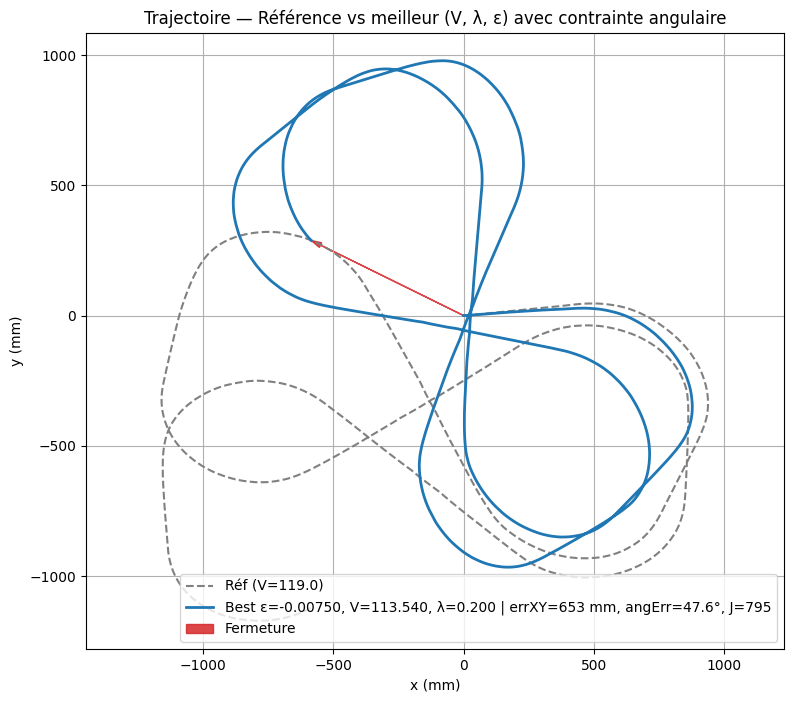

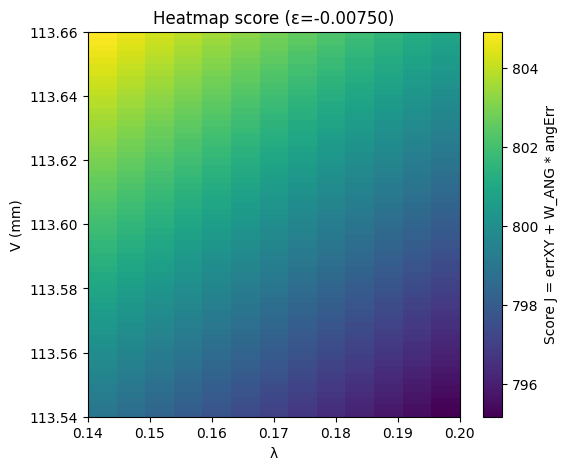


=== TOP combinaisons (score J minimal) ===
      V   lam     eps     err_xy  ang_err_deg          J          dx         dy  dtheta_deg      dist_mm
113.540 0.200 -0.0075 652.513095    47.556234 795.181797 -585.338953 288.360277  -47.556234 11142.826944
113.542 0.200 -0.0075 652.609583    47.555474 795.276004 -585.500806 288.250020  -47.555474 11142.826944
113.544 0.200 -0.0075 652.706101    47.554714 795.370242 -585.662648 288.139752  -47.554714 11142.826944
113.546 0.200 -0.0075 652.802650    47.553953 795.464511 -585.824481 288.029475  -47.553953 11142.826944
113.540 0.195 -0.0075 652.343152    47.715960 795.491033 -584.449636 289.776139  -47.715960 11142.826944
113.548 0.200 -0.0075 652.899231    47.553193 795.558811 -585.986302 287.919188  -47.553193 11142.826944
113.542 0.195 -0.0075 652.439963    47.715195 795.585550 -584.612588 289.665373  -47.715195 11142.826944
113.550 0.200 -0.0075 652.995842    47.552433 795.653142 -586.148114 287.808891  -47.552433 11142.826944
113.544 0.1

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================
# Entrées & réglages
# =============================
CSV_PATH = "FullPhysicsLog_22_10_2025_10_23_54_2025_10_22_10_23_54_278154.csv"
DT = 0.1
V_REF_OLD = 119.0   # juste pour la courbe "référence" visuelle

# Best actuel (depuis tes résultats)
EPS0 = -0.0090
V0   = 113.60
LAM0 = 0.17

# ---- Balayage ultra-fin autour du best ----
V_MIN, V_MAX, V_STEP   = V0 - 0.06, V0 + 0.06, 0.002   # 0.002 mm
LAM_MIN, LAM_MAX, dLAM = LAM0 - 0.03, LAM0 + 0.03, 0.005
EPS_MIN, EPS_MAX, dEPS = EPS0 - 0.0015, EPS0 + 0.0015, 0.00025

# Poids orientation (mm/deg)
W_ANG = 3.0

EXPORT_CSV = "best_trajectory_refined.csv"

# =============================
# Chargement
# =============================
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]
need = {"v_left_mm_s","v_right_mm_s","theta_gyro_deg"}
miss = need - set(df.columns)
if miss:
    raise RuntimeError(f"Colonnes manquantes: {miss}")

vL0 = df["v_left_mm_s"].to_numpy(float)
vR0 = df["v_right_mm_s"].to_numpy(float)
theta_gyro = np.radians(df["theta_gyro_deg"].to_numpy(float))

# =============================
# Intégrations
# =============================
def integrate_midpoint_ref(vL, vR, V, dt=DT):
    v = (vL + vR)/2.0
    w = (vR - vL)/float(V)
    n = len(v)
    x = np.zeros(n); y = np.zeros(n); th = np.zeros(n)
    for i in range(1, n):
        th_i = th[i-1] + w[i]*dt
        th_mid = 0.5*(th[i-1] + th_i)
        dd = v[i]*dt
        x[i] = x[i-1] + dd*np.cos(th_mid)
        y[i] = y[i-1] + dd*np.sin(th_mid)
        th[i] = th_i
    return x, y, th

def integrate_fusion(vL, vR, V, lam, eps=0.0, dt=DT, theta_g=theta_gyro):
    vL = (1.0 - eps)*vL
    vR = (1.0 + eps)*vR
    v  = (vL + vR)/2.0
    w  = (vR - vL)/float(V)

    n = len(v)
    th_odo = np.zeros(n)
    for i in range(1, n):
        th_odo[i] = th_odo[i-1] + w[i]*dt

    th = (1.0 - lam)*th_odo + lam*theta_g

    x = np.zeros(n); y = np.zeros(n)
    for i in range(1, n):
        th_mid = 0.5*(th[i-1] + th[i])
        dd = v[i]*dt
        x[i] = x[i-1] + dd*np.cos(th_mid)
        y[i] = y[i-1] + dd*np.sin(th_mid)

    dx, dy = float(x[-1]-x[0]), float(y[-1]-y[0])
    err_xy = float(np.hypot(dx, dy))
    dtheta_deg = float(np.degrees(th[-1] - th[0]))

    # Ecart d'angle au multiple de 360° le plus proche
    k = round(dtheta_deg / 360.0)
    ang_err = abs(dtheta_deg - 360.0*k)  # en degrés

    # Score composite
    J = err_xy + W_ANG*ang_err

    dist_mm = float(np.sum(np.maximum(v,0)*dt))
    return x, y, th, th_odo, {
        "V": V, "lam": lam, "eps": eps,
        "err_xy": err_xy, "ang_err_deg": ang_err,
        "J": J, "dx": dx, "dy": dy, "dtheta_deg": dtheta_deg,
        "dist_mm": dist_mm
    }

# =============================
# Référence visuelle
# =============================
x_ref, y_ref, _ = integrate_midpoint_ref(vL0, vR0, V_REF_OLD)

# =============================
# Balayage fin
# =============================
V_vals   = np.round(np.arange(V_MIN, V_MAX + 1e-12, V_STEP), 3)
LAM_vals = np.round(np.arange(LAM_MIN, LAM_MAX + 1e-12, dLAM), 3)
EPS_vals = np.round(np.arange(EPS_MIN, EPS_MAX + 1e-12, dEPS), 5)

records = []
best = {"J": float("inf")}

for eps in EPS_vals:
    for V in V_vals:
        for lam in LAM_vals:
            x, y, th, th_odo, m = integrate_fusion(vL0, vR0, V, lam, eps)
            records.append(m)
            if m["J"] < best["J"]:
                best = {**m, "x": x, "y": y, "th": th, "th_odo": th_odo}

grid = pd.DataFrame(records).sort_values("J").reset_index(drop=True)

# =============================
# Plots & export
# =============================
# Trajectoire best vs référence + flèche de fermeture
plt.figure(figsize=(9,8))
plt.plot(x_ref, y_ref, '--', color='gray', linewidth=1.5, label=f"Réf (V={V_REF_OLD})")
plt.plot(best["x"], best["y"], '-', linewidth=2,
         label=(f"Best ε={best['eps']:+.5f}, V={best['V']:.3f}, λ={best['lam']:.3f} | "
                f"errXY={best['err_xy']:.0f} mm, angErr={best['ang_err_deg']:.1f}°, J={best['J']:.0f}"))

x0,y0 = best["x"][0], best["y"][0]
xf,yf = best["x"][-1], best["y"][-1]
plt.arrow(x0, y0, xf-x0, yf-y0, length_includes_head=True,
          head_width=20, head_length=40, color="tab:red", alpha=0.85, label="Fermeture")

plt.xlabel("x (mm)"); plt.ylabel("y (mm)")
plt.title("Trajectoire — Référence vs meilleur (V, λ, ε) avec contrainte angulaire")
plt.grid(True); plt.axis("equal"); plt.legend()
plt.show()

# Heatmap pour eps = best (si tu veux comparer V/λ à eps fixé)
rows = grid[np.isclose(grid["eps"], best["eps"])]
if not rows.empty:
    pv = rows.pivot(index="V", columns="lam", values="J").sort_index()
    plt.figure(figsize=(6,5))
    im = plt.imshow(pv.values, origin="lower", aspect="auto",
                    extent=[pv.columns.min(), pv.columns.max(), pv.index.min(), pv.index.max()])
    plt.colorbar(im, label="Score J = errXY + W_ANG * angErr")
    plt.xlabel("λ"); plt.ylabel("V (mm)")
    plt.title(f"Heatmap score (ε={best['eps']:+.5f})")
    plt.show()

# Top résultats
print("\n=== TOP combinaisons (score J minimal) ===")
print(grid.head(15).to_string(index=False))

print(f"\n>>> BEST: ε={best['eps']:+.5f}, V={best['V']:.3f}, λ={best['lam']:.3f} | "
      f"errXY={best['err_xy']:.1f} mm | angErr={best['ang_err_deg']:.2f}° | J={best['J']:.1f} | "
      f"Δx={best['dx']:.1f}, Δy={best['dy']:.1f} | Δθ={best['dtheta_deg']:.1f}°")

# Export CSV
out = pd.DataFrame({
    "t_s": np.arange(len(best["x"])) * DT,
    "x_mm": best["x"],
    "y_mm": best["y"],
    "theta_deg": np.degrees(best["th"])
})
out.to_csv(EXPORT_CSV, index=False)
print(f"\nFichier exporté: {EXPORT_CSV}")



-- Angle closure --
Bias w_bias = -0.002285 rad/s (angErr avant 38.30°, après 0.01°)
Erreur XY après fermeture angle: 510.4 mm (avant 121.0 mm)


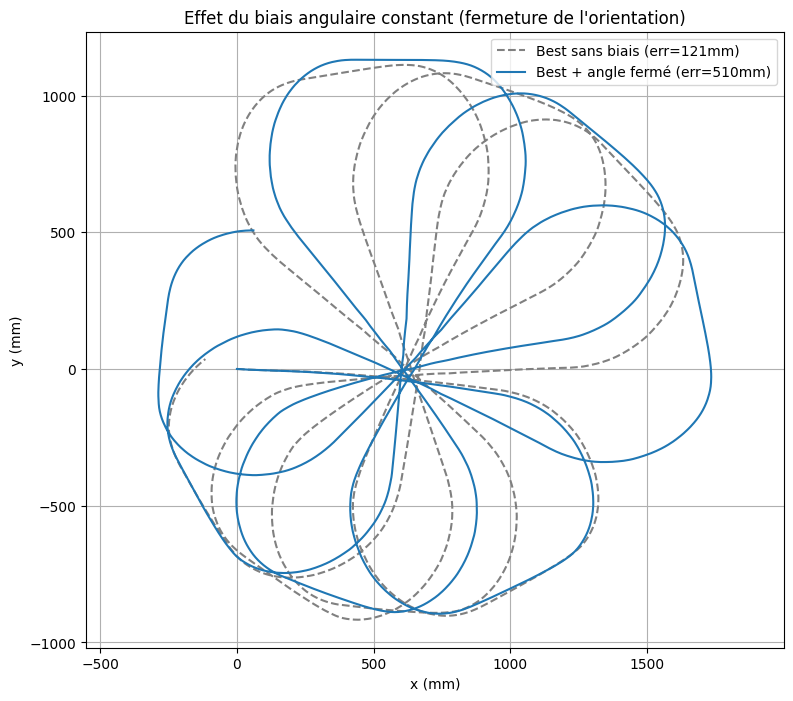

In [ ]:
import numpy as np

def tapered_angle_correction(th, dt, taper_frac=0.20, window="hann"):
    """
    th : angle fusionné (rad) sur toute la durée
    dt : pas (s)
    taper_frac : fraction de la durée sur laquelle on corrige (ex: 0.20 = 20% final)
    window : type de fenêtre ("hann" conseillé)

    Retourne theta_corr, ang_err_before_deg, ang_err_after_deg
    """
    n = len(th)
    T = n * dt
    dtheta = float(th[-1] - th[0])          # angle total (rad)
    # cible = multiple de 2π le plus proche
    k = int(round(dtheta / (2*np.pi)))
    theta_target = 2*np.pi * k
    delta_needed = theta_target - dtheta    # rad à ajouter au total

    # Fenêtre sur la fin
    m = max(4, int(np.round(taper_frac * n)))
    w = np.ones(n) * 0.0
    if window.lower() == "hann":
        w_tail = 0.5 * (1.0 - np.cos(2*np.pi*np.arange(m)/ (m-1)))  # Hann
    else:
        w_tail = np.ones(m)
    w[-m:] = w_tail

    # Normalisation pour que l'intégrale de la correction = delta_needed
    # On ajoute un petit "drift local" : w_bias(t) = A * w(t)
    # Total angle ajouté = sum_t [A * w(t)] * dt = A * dt * sum(w) = delta_needed
    denom = dt * float(np.sum(w))
    if denom == 0.0:
        return th.copy(), abs(np.degrees(dtheta - theta_target)), abs(np.degrees(dtheta - theta_target))
    A = delta_needed / denom

    # Construire la correction angulaire cumulée: theta_corr[i] = th[i] + integral_0^t A*w(τ) dτ
    theta_corr = np.array(th, dtype=float)
    # Intégrer A*w(t) sur le temps (Riemann)
    cum = 0.0
    for i in range(1, n):
        cum += A * w[i] * dt
        theta_corr[i] += cum

    ang_before = abs(np.degrees(dtheta - theta_target))
    ang_after  = abs(np.degrees((theta_corr[-1]-theta_corr[0]) - theta_target))
    return theta_corr, ang_before, ang_after

def reintegrate_with_theta(vL0, vR0, V, eps, dt, theta_given):
    """Réintègre x,y en imposant theta_given (rad), asymétrie ε sur vL/vR."""
    vL = (1.0 - eps)*vL0
    vR = (1.0 + eps)*vR0
    v  = (vL + vR)/2.0

    x = np.zeros_like(theta_given); y = np.zeros_like(theta_given)
    for i in range(1, len(theta_given)):
        th_mid = 0.5*(theta_given[i-1] + theta_given[i])
        dd = v[i]*dt
        x[i] = x[i-1] + dd*np.cos(th_mid)
        y[i] = y[i-1] + dd*np.sin(th_mid)
    dx, dy = float(x[-1]-x[0]), float(y[-1]-y[0])
    err_xy = float(np.hypot(dx, dy))
    return x, y, err_xy

# === Fermeture d'angle fenêtrée (fin de run) ===
theta_corr, ang_before, ang_after = tapered_angle_correction(best["th"], DT, taper_frac=0.20, window="hann")
x_c, y_c, err_c = reintegrate_with_theta
